# TUGAS PERTEMUAN 9 DATA SCIENCE

**Nama Lengkap:** IKRAM  
**NIM:** 240401020139  
**Kelas:** IF 405

In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dimensi data (baris, kolom):", X.shape)
print("\nDistribusi kelas target (proporsi):")
print(pd.Series(y).value_counts(normalize=True).round(3))

Dimensi data (baris, kolom): (569, 30)

Distribusi kelas target (proporsi):
1    0.627
0    0.373
Name: proportion, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data berhasil dibagi dan distandarisasi.")
print("Jumlah data training:", X_train_scaled.shape[0])
print("Jumlah data testing:", X_test_scaled.shape[0])

Data berhasil dibagi dan distandarisasi.
Jumlah data training: 455
Jumlah data testing: 114


In [4]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': log_model.coef_[0]
}).sort_values('Koefisien', key=abs, ascending=False)

print("Model Logistic Regression berhasil dilatih.")
print("\nTop 5 Fitur Paling Berpengaruh:")
print(coef_df.head())

Model Logistic Regression berhasil dilatih.

Top 5 Fitur Paling Berpengaruh:
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


Model Decision Tree berhasil dilatih. Menampilkan visualisasi pohon:


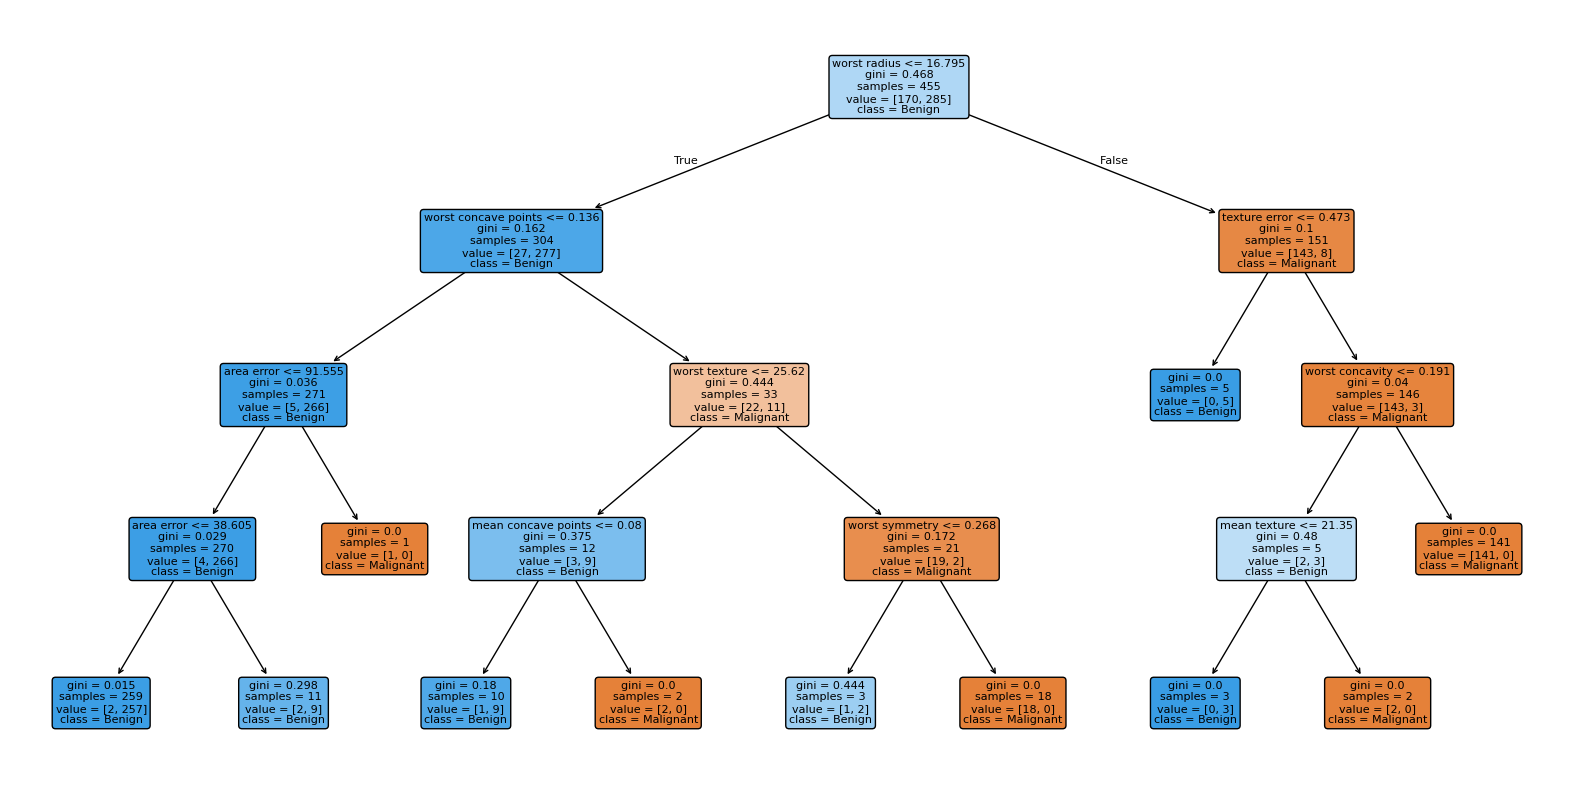

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Model Decision Tree berhasil dilatih. Menampilkan visualisasi pohon:")

plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], filled=True, rounded=True)
plt.show()

In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("\n[ LOGISTIC REGRESSION ]")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print(f"Accuracy  : {accuracy_score(y_test, y_pred_log):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_log):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_log):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_log):.3f}")

print("\n[ DECISION TREE ]")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))
print(f"Accuracy  : {accuracy_score(y_test, y_pred_tree):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_tree):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_tree):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_tree):.3f}")


[ LOGISTIC REGRESSION ]
Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy  : 0.982
Precision : 0.986
Recall    : 0.986
F1-Score  : 0.986

[ DECISION TREE ]
Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy  : 0.939
Precision : 0.958
Recall    : 0.944
F1-Score  : 0.951


### Analisis Hasil & Perbandingan Model

Berikut adalah analisis singkat berdasarkan hasil pengujian kedua model pada data test:

#### 1. Hasil Metrik Evaluasi
*   **Logistic Regression**: Accuracy (98.2%), Precision (98.6%), Recall (98.6%), F1-Score (98.6%).
*   **Decision Tree**: Accuracy (93.9%), Precision (95.8%), Recall (94.4%), F1-Score (95.1%).

#### 2. Model dengan Recall Terbaik
Model **Logistic Regression** punya nilai Recall yang lebih tinggi (98.6%) dibandingkan Decision Tree (94.4%). Kalau dilihat dari confusion matrix, Logistic Regression cuma salah menebak 1 pasien (False Negative), sedangkan Decision Tree salah sampai 4 pasien.

#### 3. Kenapa Recall Sangat Penting di Kasus Medis?
Dalam diagnosis penyakit kritis seperti kanker, **Recall jauh lebih krusial daripada akurasi biasa**.
*   Jika nilai Recall rendah, artinya banyak pasien yang sebenarnya punya kanker ganas malah dikira sehat (False Negative). Ini sangat berbahaya karena mereka tidak akan mendapat pengobatan dan bisa berakibat fatal.
*   Sebaliknya, kalau terjadi False Positive (pasien sehat dikira sakit), mereka tinggal ikut tes lanjutan atau biopsi untuk memastikan. Efeknya cuma cemas sesaat, tidak sampai mengancam nyawa. Jadi, kita butuh model yang bisa meminimalkan False Negative sekecil mungkin.

#### 4. Kesimpulan Perbandingan
Ada perbedaan performa yang lumayan kelihatan, di mana **Logistic Regression menang di semua metrik**. Hal ini wajar karena karakteristik dataset kanker payudara ini punya fitur numerik yang polanya cenderung linier (mudah dipisahkan dengan garis lurus oleh fungsi sigmoid). Sementara itu, Decision Tree dengan batas `max_depth=4` membagi datanya agak kaku lewat percabangan *if-else*, sehingga hasilnya sedikit di bawah Logistic Regression.